HW01

2.1

1. 向量点积 a · b

a · b = 2 × 1 + (-1) × 4 + 3 × (-2)= -8

2. 矩阵乘法 A × B（结果矩阵的形状？）

A 的形状：4 × 3

B 的形状：3 × 2

结果矩阵的形状：4 × 2

计算过程：

第1行第1列：[3,5,4] · [1,3,5]^T = 3 + 15 + 20 = 38

第1行第2列：[3,5,4] · [2,4,6]^T = 6 + 20 + 24 = 50

第2行第1列：[5,5,6] · [1,3,5]^T = 5 + 15 + 30 = 50

第2行第2列：[5,5,6] · [2,4,6]^T = 10 + 20 + 36 = 66

第3行第1列：[6,3,8] · [1,3,5]^T = 6 + 9 + 40 = 55

第3行第2列：[6,3,8] · [2,4,6]^T = 12 + 12 + 48 = 72

第4行第1列：[6,1,8] · [1,3,5]^T = 6 + 3 + 40 = 49

第4行第2列：[6,1,8] · [2,4,6]^T = 12 + 4 + 48 = 64

结果：

A × B =
[38, 50]
[50, 66]
[55, 72]
[49, 64]

3. 向量 a 的 Frobenius 范数

||a||_F = √(2^2 + (-1)^2 + 3^2)= √(4 + 1 + 9)= √14

2.2

In [1]:
import numpy as np

# 创建一个形状为 3x4 的随机矩阵 X，元素服从标准正态分布
np.random.seed(42)  
X = np.random.randn(3, 4)
print("1. 随机矩阵 X (3x4，标准正态分布):")
print(X)
print()

# 创建一个形状为 4x2 的全1矩阵 Y
Y = np.ones((4, 2))
print("2. 全1矩阵 Y (4x2):")
print(Y)
print()

# 计算矩阵乘法 Z = X × Y
Z = np.dot(X, Y)
print("3. 矩阵乘法 Z = X × Y (3x2):")
print(Z)
print()

# 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第2行所有元素
element = Z[0, 1]  # 第一行第二列（索引从0开始）
row2 = Z[1, :]     # 第二行所有元素
print("4. Z的第一行第二列交叉处的元素:", element)
print("   Z的第二行所有元素:", row2)
print()

# 计算 Z 的 Frobenius 范数
frobenius_norm = np.linalg.norm(Z, 'fro')
print("5. Z的Frobenius范数:", frobenius_norm)

1. 随机矩阵 X (3x4，标准正态分布):
[[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]

2. 全1矩阵 Y (4x2):
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

3. 矩阵乘法 Z = X × Y (3x2):
[[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]

4. Z的第一行第二列交叉处的元素: 2.5291682463487657
   Z的第二行所有元素: [1.87835721 1.87835721]

5. Z的Frobenius范数: 4.616873319476863


3.1

定义事件：
D：患病
T：检测阳性

已知：
P(D) = 0.001
P(¬D) = 0.999
P(T|D) = 0.99
P(T|¬D) = 0.02

P(D|T) = P(T|D)P(D) / [P(T|D)P(D) + P(T|¬D)P(¬D)]
= (0.99 × 0.001) / (0.99 × 0.001 + 0.02 × 0.999)
= 0.00099 / (0.00099 + 0.01998)
= 0.00099 / 0.02097
≈ 0.04721

结论：检测结果为阳性时，真正患病的概率约为 4.72%。

3.2

C:\Users\lenovo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


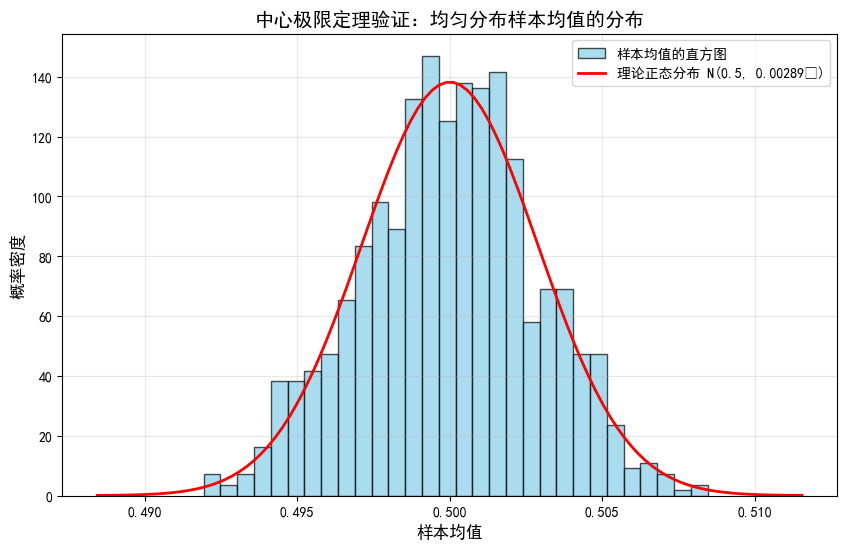

中心极限定理模拟结果
1. 参数设置:
   - 每次采样样本数 n = 10000
   - 重复次数 m = 1000
   - 原始分布: 均匀分布 U(0,1)

2. 样本均值的统计量:
   - 实际均值: 0.499992
   - 理论均值: 0.500000
   - 差值: 7.519616e-06

3. 样本均值的方差:
   - 实际方差: 0.00000828
   - 理论方差: 0.00000833
   - 相对误差: 0.69%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

n = 10000  
m = 1000   

np.random.seed(42)
sample_means = []

for i in range(m):
    # 从均匀分布 U(0,1) 中抽取 n 个样本
    samples = np.random.uniform(0, 1, n)
    # 计算均值
    sample_means.append(np.mean(samples))

sample_means = np.array(sample_means)

# 绘制直方图和理论正态分布曲线
fig, ax = plt.subplots(figsize=(10, 6))

# 绘制直方图
count, bins, patches = ax.hist(sample_means, bins=30, density=True, 
                                alpha=0.7, color='skyblue', edgecolor='black', 
                                label='样本均值的直方图')

mu_theory = 0.5
sigma_theory = np.sqrt(1 / (12 * n))
x = np.linspace(mu_theory - 4*sigma_theory, mu_theory + 4*sigma_theory, 100)
y = stats.norm.pdf(x, mu_theory, sigma_theory)
ax.plot(x, y, 'r-', linewidth=2, label=f'理论正态分布 N({mu_theory}, {sigma_theory:.5f}²)')

ax.set_xlabel('样本均值', fontsize=12)
ax.set_ylabel('概率密度', fontsize=12)
ax.set_title('中心极限定理验证：均匀分布样本均值的分布', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

# 计算这些均值的实际方差
actual_mean = np.mean(sample_means)
actual_variance = np.var(sample_means, ddof=0)  # 总体方差
theoretical_variance = 1 / (12 * n)

print("="*50)
print("中心极限定理模拟结果")
print("="*50)
print(f"1. 参数设置:")
print(f"   - 每次采样样本数 n = {n}")
print(f"   - 重复次数 m = {m}")
print(f"   - 原始分布: 均匀分布 U(0,1)")
print()
print(f"2. 样本均值的统计量:")
print(f"   - 实际均值: {actual_mean:.6f}")
print(f"   - 理论均值: {mu_theory:.6f}")
print(f"   - 差值: {abs(actual_mean - mu_theory):.6e}")
print()
print(f"3. 样本均值的方差:")
print(f"   - 实际方差: {actual_variance:.8f}")
print(f"   - 理论方差: {theoretical_variance:.8f}")
print(f"   - 相对误差: {abs(actual_variance - theoretical_variance)/theoretical_variance*100:.2f}%")

4.1

1. 分别计算 ∂z/∂w1 和 ∂z/∂w2 的表达式

令 u = w1·x1 + w2·x2 - y，则 z = u^2

由链式法则：

∂z/∂w1 = (∂z/∂u) × (∂u/∂w1) = 2u × x1

= 2(w1·x1 + w2·x2 - y) × x1

代入 x1 = 2，x2 = 1，y = 3：

∂z/∂w1 = 2(2w1 + w2 - 3) × 2 = 4(2w1 + w2 - 3)

同理：

∂z/∂w2 = (∂z/∂u) × (∂u/∂w2) = 2u × x2

= 2(w1·x1 + w2·x2 - y) × x2

= 2(2w1 + w2 - 3) × 1 = 2(2w1 + w2 - 3)

2. 若当前 w1 = 0.5，w2 = 1，计算梯度值

先计算中间值：

2w1 + w2 - 3 = 2 × 0.5 + 1 - 3 = 1 + 1 - 3 = -1

则：

∂z/∂w1 = 4 × (-1) = -4

∂z/∂w2 = 2 × (-1) = -2

梯度 ∇z = (-4, -2)

4.2

In [1]:
import torch

print("="*50)
print("手动实现计算图的反向传播")
print("="*50)

x = 2.0
w1 = 1.5
w2 = 0.5

print(f"\n输入参数:")
print(f"  x = {x}")
print(f"  w1 = {w1}")
print(f"  w2 = {w2}")

# 前向计算
a = x * w1
b = a + w2
L = b ** 2

print(f"\n前向计算结果:")
print(f"  a = x * w1 = {x} * {w1} = {a}")
print(f"  b = a + w2 = {a} + {w2} = {b}")
print(f"  L = b^2 = {b}^2 = {L}")

dL_db = 2 * b
dL_da = dL_db * 1  
dL_dw1 = dL_da * x  
dL_dw2 = dL_db * 1  

print(f"\n手动计算的梯度:")
print(f"  ∂L/∂w1 = ∂L/∂b * ∂b/∂a * ∂a/∂w1 = {dL_db} * 1 * {x} = {dL_dw1}")
print(f"  ∂L/∂w2 = ∂L/∂b * ∂b/∂w2 = {dL_db} * 1 = {dL_dw2}")

# 使用 PyTorch 的自动微分验证
# 创建张量并设置 requires_grad=True
x_t = torch.tensor(x, requires_grad=False)
w1_t = torch.tensor(w1, requires_grad=True)
w2_t = torch.tensor(w2, requires_grad=True)

# 前向计算
a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2

# 反向传播
L_t.backward()

print(f"\nPyTorch自动微分计算的梯度:")
print(f"  ∂L/∂w1 = {w1_t.grad.item()}")
print(f"  ∂L/∂w2 = {w2_t.grad.item()}")

# 验证结果是否一致
print(f"\n验证结果:")
print(f"  手动计算 vs PyTorch (w1): {dL_dw1} vs {w1_t.grad.item()}")
print(f"  手动计算 vs PyTorch (w2): {dL_dw2} vs {w2_t.grad.item()}")

if abs(dL_dw1 - w1_t.grad.item()) < 1e-6 and abs(dL_dw2 - w2_t.grad.item()) < 1e-6:
    print("  验证通过！手动计算与自动微分结果一致。")
else:
    print("  验证失败！")

手动实现计算图的反向传播

输入参数:
  x = 2.0
  w1 = 1.5
  w2 = 0.5

前向计算结果:
  a = x * w1 = 2.0 * 1.5 = 3.0
  b = a + w2 = 3.0 + 0.5 = 3.5
  L = b^2 = 3.5^2 = 12.25

手动计算的梯度:
  ∂L/∂w1 = ∂L/∂b * ∂b/∂a * ∂a/∂w1 = 7.0 * 1 * 2.0 = 14.0
  ∂L/∂w2 = ∂L/∂b * ∂b/∂w2 = 7.0 * 1 = 7.0

PyTorch自动微分计算的梯度:
  ∂L/∂w1 = 14.0
  ∂L/∂w2 = 7.0

验证结果:
  手动计算 vs PyTorch (w1): 14.0 vs 14.0
  手动计算 vs PyTorch (w2): 7.0 vs 7.0
  验证通过！手动计算与自动微分结果一致。


5.1

令 ŷ_i = w x_i + b，则：

L = (1/n) × Σ_{i=1}^{n} (y_i - ŷ_i)^2

对 w 求偏导：

∂L/∂w = (1/n) × Σ_{i=1}^{n} 2(y_i - w x_i - b) × (-x_i)

= -(2/n) × Σ_{i=1}^{n} x_i (y_i - w x_i - b)

对 b 求偏导：

∂L/∂b = (1/n) × Σ_{i=1}^{n} 2(y_i - w x_i - b) × (-1)

= -(2/n) × Σ_{i=1}^{n} (y_i - w x_i - b)

最终结果：

∂L/∂w = -(2/n) Σ_{i=1}^{n} x_i (y_i - w x_i - b)

∂L/∂b = -(2/n) Σ_{i=1}^{n} (y_i - w x_i - b)

5.2

Softmax回归实现 - MNIST手写数字分类

数据集信息:
  样本数量: 1797
  特征维度: 64
  类别数量: 10
  训练集大小: 1437
  测试集大小: 360
  One-hot编码后标签维度: 10

训练参数:
  批量大小: 32
  学习率: 0.1
  Epoch数: 50

开始训练...
------------------------------------------------------------
Epoch  10/50 | Loss: 0.1416 | Train Acc: 0.9756 | Test Acc: 0.9583
Epoch  20/50 | Loss: 0.0936 | Train Acc: 0.9889 | Test Acc: 0.9639
Epoch  30/50 | Loss: 0.0738 | Train Acc: 0.9896 | Test Acc: 0.9750
Epoch  40/50 | Loss: 0.0609 | Train Acc: 0.9903 | Test Acc: 0.9750
Epoch  50/50 | Loss: 0.0533 | Train Acc: 0.9916 | Test Acc: 0.9722
------------------------------------------------------------

最终测试集准确率: 0.9722 (97.22%)


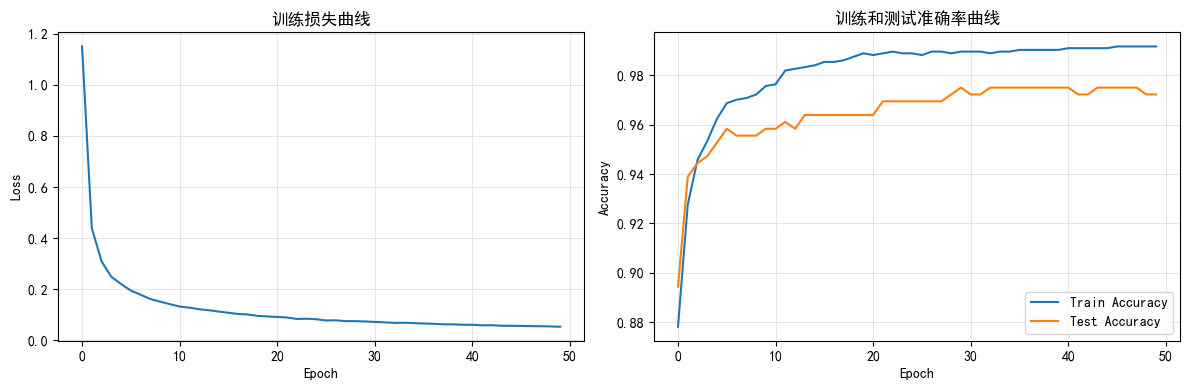

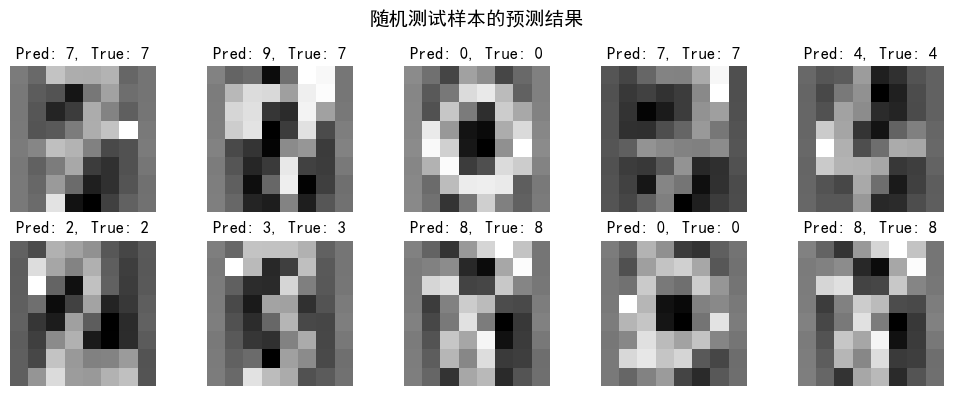

In [ ]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

np.random.seed(42)

print("="*60)
print("Softmax回归实现 - MNIST手写数字分类")
print("="*60)

digits = load_digits()
X = digits.data  # (1797, 64)
y = digits.target  # (1797,)

print(f"\n数据集信息:")
print(f"  样本数量: {X.shape[0]}")
print(f"  特征维度: {X.shape[1]}")
print(f"  类别数量: {len(np.unique(y))}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"  训练集大小: {X_train.shape[0]}")
print(f"  测试集大小: {X_test.shape[0]}")

# 标准化
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
std[std == 0] = 1
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# One-hot编码
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_onehot = encoder.transform(y_test.reshape(-1, 1))

num_classes = y_train_onehot.shape[1]
print(f"  One-hot编码后标签维度: {num_classes}")

# 实现Softmax回归
class SoftmaxRegression:
    def __init__(self, input_dim, num_classes, learning_rate=0.1):
        # Xavier初始化
        self.W = np.random.randn(input_dim, num_classes) * np.sqrt(2.0 / input_dim)
        self.b = np.zeros(num_classes)
        self.lr = learning_rate
    
    def softmax(self, logits):
        """Softmax函数"""
        exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
        return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
    
    def cross_entropy_loss(self, y_pred, y_true):
        """交叉熵损失函数"""
        n = y_pred.shape[0]
        loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / n
        return loss
    
    def forward(self, X):
        """前向传播"""
        logits = X @ self.W + self.b
        return self.softmax(logits)
    
    def backward(self, X, y_true, y_pred):
        """反向传播"""
        n = X.shape[0]
        grad_logits = y_pred - y_true
        grad_W = (X.T @ grad_logits) / n
        grad_b = np.sum(grad_logits, axis=0) / n
        return grad_W, grad_b
    
    def update(self, grad_W, grad_b):
        """更新参数"""
        self.W -= self.lr * grad_W
        self.b -= self.lr * grad_b
    
    def predict(self, X):
        """预测"""
        y_pred = self.forward(X)
        return np.argmax(y_pred, axis=1)
    
    def accuracy(self, X, y):
        """计算准确率"""
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

#模型
model = SoftmaxRegression(input_dim=64, num_classes=10, learning_rate=0.1)
batch_size = 32
epochs = 50
num_batches = len(X_train) // batch_size

train_losses = []
train_accs = []
test_accs = []

print(f"\n训练参数:")
print(f"  批量大小: {batch_size}")
print(f"  学习率: 0.1")
print(f"  Epoch数: {epochs}")

print("\n开始训练...")
print("-"*60)

for epoch in range(epochs):
    # 打乱训练数据
    indices = np.random.permutation(len(X_train))
    X_shuffled = X_train[indices]
    y_shuffled = y_train_onehot[indices]
    
    epoch_loss = 0
    
    # 小批量梯度下降
    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = start_idx + batch_size
        
        X_batch = X_shuffled[start_idx:end_idx]
        y_batch = y_shuffled[start_idx:end_idx]
        
        # 前向传播
        y_pred = model.forward(X_batch)
        
        # 计算损失
        loss = model.cross_entropy_loss(y_pred, y_batch)
        epoch_loss += loss
        
        # 反向传播
        grad_W, grad_b = model.backward(X_batch, y_batch, y_pred)
        
        # 更新参数
        model.update(grad_W, grad_b)
    
    # 记录训练和测试指标
    avg_loss = epoch_loss / num_batches
    train_acc = model.accuracy(X_train, y_train)
    test_acc = model.accuracy(X_test, y_test)
    
    train_losses.append(avg_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

print("-"*60)

# 输出测试集上的准确率
final_test_acc = model.accuracy(X_test, y_test)
print(f"\n最终测试集准确率: {final_test_acc:.4f} ({final_test_acc*100:.2f}%)")

# 绘制训练曲线
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('训练损失曲线')
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, label='Train Accuracy')
axes[1].plot(test_accs, label='Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('训练和测试准确率曲线')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 显示一些预测结果
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(X_test))
    img = X_test[idx].reshape(8, 8)
    pred = model.predict(X_test[idx:idx+1])[0]
    true = y_test[idx]
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Pred: {pred}, True: {true}')
    ax.axis('off')
plt.suptitle('随机测试样本的预测结果', fontsize=14)
plt.tight_layout()
plt.show()

6.1

假设样本 x₁, x₂, ..., x_n 独立同分布于正态分布 N(μ, σ²)。

1. 写出似然函数 L(μ, σ²)

正态分布的概率密度函数：

f(x_i | μ, σ²) = 1 / √(2πσ²) × exp[ -(x_i - μ)² / (2σ²) ]

似然函数：

L(μ, σ²) = ∏_{i=1}^{n} f(x_i | μ, σ²)

= (2πσ²)^(-n/2) × exp[ -(1/(2σ²)) × Σ_{i=1}^{n} (x_i - μ)² ]

对数似然函数：

ℓ(μ, σ²) = -(n/2) ln(2π) - (n/2) ln(σ²) - (1/(2σ²)) × Σ_{i=1}^{n} (x_i - μ)²


2. 证明：μ 的最大似然估计为 \hat{μ} = (1/n) Σ_{i=1}^{n} x_i

对 μ 求偏导：

∂ℓ/∂μ = (1/σ²) × Σ_{i=1}^{n} (x_i - μ)

令偏导数为 0：

(1/σ²) × Σ_{i=1}^{n} (x_i - μ) = 0

Σ_{i=1}^{n} x_i - nμ = 0

解得：

\hat{μ} = (1/n) × Σ_{i=1}^{n} x_i


3. 证明：σ² 的最大似然估计为 \hat{σ}² = (1/n) Σ_{i=1}^{n} (x_i - \hat{μ})²

令 θ = σ²，对 θ 求偏导：

∂ℓ/∂θ = -n/(2θ) + (1/(2θ²)) × Σ_{i=1}^{n} (x_i - μ)²

令偏导数为 0：

-n/(2θ) + (1/(2θ²)) × Σ_{i=1}^{n} (x_i - μ)² = 0

两边乘以 2θ²：

-nθ + Σ_{i=1}^{n} (x_i - μ)² = 0

解得：

\hat{θ} = (1/n) × Σ_{i=1}^{n} (x_i - μ)²

代入 \hat{μ}：

\hat{σ}² = (1/n) × Σ_{i=1}^{n} (x_i - \hat{μ})²

6.2

二分类逻辑回归实现

数据集信息:
  训练集: 400 个样本
  测试集: 200 个样本
  特征维度: 2

训练参数:
  学习率: 0.1
  迭代次数: 1000

开始训练...
------------------------------------------------------------
迭代  200/1000 | Loss: 0.1708 | Train Acc: 1.0000
迭代  400/1000 | Loss: 0.0942 | Train Acc: 1.0000
迭代  600/1000 | Loss: 0.0651 | Train Acc: 1.0000
迭代  800/1000 | Loss: 0.0499 | Train Acc: 1.0000
迭代 1000/1000 | Loss: 0.0406 | Train Acc: 1.0000
------------------------------------------------------------

模型性能:
  训练集准确率: 1.0000 (100.00%)
  测试集准确率: 1.0000 (100.00%)

绘制决策边界...


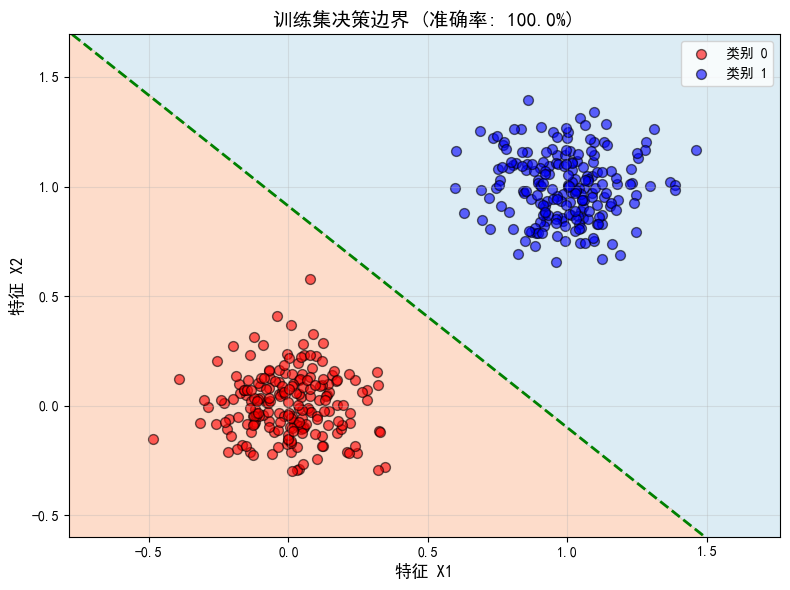

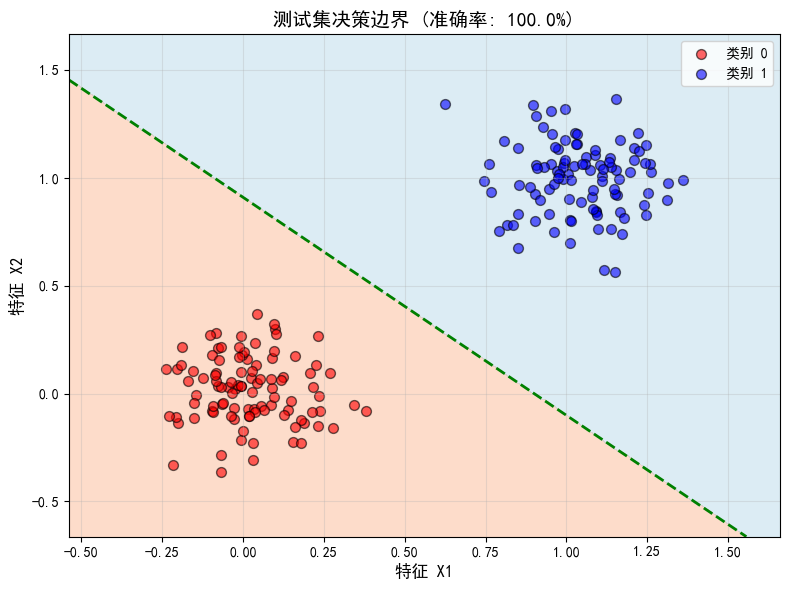

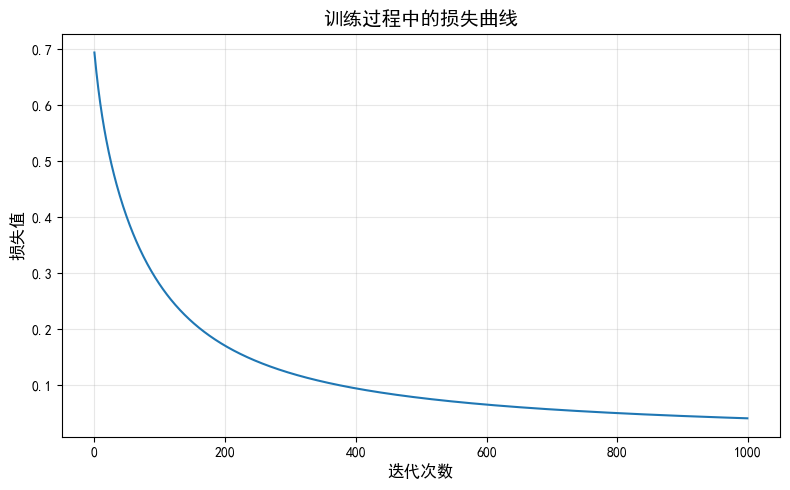


学习到的模型参数:
  w1 = 3.5259
  w2 = 3.4854
  b = -3.1752
  决策边界方程: 3.5259 * x1 + 3.4854 * x2 + -3.1752 = 0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

print("="*60)
print("二分类逻辑回归实现")
print("="*60)

# 生成两类线性可分的数据
def generate_data(n_samples=200, noise=0.1):
    """生成线性可分的二分类数据"""
    # 类别0：以 (0, 0) 为中心
    class0 = np.random.randn(n_samples, 2) * noise + np.array([0, 0])
    # 类别1：以 (1, 1) 为中心
    class1 = np.random.randn(n_samples, 2) * noise + np.array([1, 1])
    
    X = np.vstack([class0, class1])
    y = np.hstack([np.zeros(n_samples), np.ones(n_samples)])
    
    return X, y

X_train, y_train = generate_data(200, noise=0.15)
X_test, y_test = generate_data(100, noise=0.15)

print(f"\n数据集信息:")
print(f"  训练集: {X_train.shape[0]} 个样本")
print(f"  测试集: {X_test.shape[0]} 个样本")
print(f"  特征维度: {X_train.shape[1]}")

# 实现逻辑回归
class LogisticRegression:
    def __init__(self, learning_rate=0.1, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.W = None
        self.b = None
        self.losses = []
    
    def sigmoid(self, z):
        """Sigmoid函数"""
        # 防止数值溢出
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def binary_cross_entropy(self, y_pred, y_true):
        """二元交叉熵损失"""
        # 防止log(0)
        y_pred = np.clip(y_pred, 1e-8, 1 - 1e-8)
        loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        return loss
    
    def fit(self, X, y):
        """训练模型"""
        n_samples, n_features = X.shape
        
        # 初始化参数
        self.W = np.random.randn(n_features) * 0.01
        self.b = 0
        
        print(f"\n训练参数:")
        print(f"  学习率: {self.lr}")
        print(f"  迭代次数: {self.n_iterations}")
        
        print("\n开始训练...")
        print("-"*60)
        
        for i in range(self.n_iterations):
            # 前向传播
            linear_model = X @ self.W + self.b
            y_pred = self.sigmoid(linear_model)
            
            # 计算损失
            loss = self.binary_cross_entropy(y_pred, y)
            self.losses.append(loss)
            
            # 反向传播（梯度计算）
            dw = (1/n_samples) * (X.T @ (y_pred - y))
            db = (1/n_samples) * np.sum(y_pred - y)
            
            # 更新参数
            self.W -= self.lr * dw
            self.b -= self.lr * db
            
            # 打印进度
            if (i + 1) % 200 == 0:
                acc = self.accuracy(X, y)
                print(f"迭代 {i+1:4d}/{self.n_iterations} | Loss: {loss:.4f} | Train Acc: {acc:.4f}")
        
        print("-"*60)
    
    def predict_proba(self, X):
        """预测概率"""
        linear_model = X @ self.W + self.b
        return self.sigmoid(linear_model)
    
    def predict(self, X, threshold=0.5):
        """预测类别"""
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)
    
    def accuracy(self, X, y):
        """计算准确率"""
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

# 训练模型
model = LogisticRegression(learning_rate=0.1, n_iterations=1000)
model.fit(X_train, y_train)

# 计算测试集准确率
train_acc = model.accuracy(X_train, y_train)
test_acc = model.accuracy(X_test, y_test)

print(f"\n模型性能:")
print(f"  训练集准确率: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"  测试集准确率: {test_acc:.4f} ({test_acc*100:.2f}%)")

# 绘制决策边界
def plot_decision_boundary(model, X, y, title):
    """绘制决策边界"""
    plt.figure(figsize=(8, 6))
    
    # 创建网格
    x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # 预测网格点的类别
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid_points)
    Z = Z.reshape(xx.shape)
    
    # 绘制决策边界（不直接使用contourf的返回值作为colorbar）
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu, levels=[-0.5, 0.5, 1.5])
    
    # 绘制数据点
    plt.scatter(X[y==0, 0], X[y==0, 1], c='red', label='类别 0', alpha=0.6, edgecolors='k', s=50)
    plt.scatter(X[y==1, 0], X[y==1, 1], c='blue', label='类别 1', alpha=0.6, edgecolors='k', s=50)
    
    # 绘制决策线（概率为0.5的等高线）
    proba_grid = model.predict_proba(grid_points).reshape(xx.shape)
    plt.contour(xx, yy, proba_grid, levels=[0.5], colors='green', linewidths=2, linestyles='--')
    
    plt.xlabel('特征 X1', fontsize=12)
    plt.ylabel('特征 X2', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 修复字符串格式化问题
print("\n绘制决策边界...")
plot_decision_boundary(model, X_train, y_train, f'训练集决策边界 (准确率: {train_acc*100:.1f}%)')
plot_decision_boundary(model, X_test, y_test, f'测试集决策边界 (准确率: {test_acc*100:.1f}%)')

# 绘制损失曲线
plt.figure(figsize=(8, 5))
plt.plot(model.losses)
plt.xlabel('迭代次数', fontsize=12)
plt.ylabel('损失值', fontsize=12)
plt.title('训练过程中的损失曲线', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 输出最终参数
print(f"\n学习到的模型参数:")
print(f"  w1 = {model.W[0]:.4f}")
print(f"  w2 = {model.W[1]:.4f}")
print(f"  b = {model.b:.4f}")
print(f"  决策边界方程: {model.W[0]:.4f} * x1 + {model.W[1]:.4f} * x2 + {model.b:.4f} = 0")
